# Bank Heist

Small text adventure: reach the vault by entering the correct **PIN** on the keypad (hint on a sticky note in the lobby), grab the cash, and escape to the alley. Wrong PIN trips the silent alarm.

**Do not** try to leave through the lobby side exit.

In [1]:
import re

from text_adventure_games import games, parsing, actions, things, blocks

## Map

- **Lobby** → south: **Security corridor** → east (blocked until PIN): **Vault** → north: **Getaway Alley** (win).
- **Lobby** → east: **Caught** (game over).

In [2]:
CORRECT_PIN = "7301"

lobby = things.Location(
    "Lobby",
    "You are in an empty bank lobby after hours. Exits lead deeper into the building.",
)
corridor = things.Location(
    "Security corridor",
    "Dim hallway toward the vault. A keypad sits beside the vault door.",
)
vault = things.Location(
    "Vault",
    "Steel walls and deposit boxes. Bundles of cash sit on a cart.",
)
alley = things.Location(
    "Getaway Alley",
    "A narrow alley behind the bank. Fresh air.",
)
caught = things.Location(
    "Too late",
    "Lights and sirens. Plainclothes officers were staking out an adjacent door. GAME OVER.",
)
caught.set_property("game_over", True)

lobby.add_connection("south", corridor)
lobby.add_connection("east", caught)
corridor.add_connection("east", vault)
vault.add_connection("north", alley)

## Items (memo, keypad, cash)

In [3]:
memo = things.Item(
    "memo",
    "a sticky note",
    "Someone scribbled: Vault interim PIN today is 7301. Don't leave this lying around.",
)
lobby.add_item(memo)

keypad = things.Item(
    "keypad",
    "a numeric keypad",
    "Twelve rubberized buttons and a small LCD. Try entering the vault PIN.",
)
keypad.set_property("gettable", False)
keypad.set_property("unlocked", False)
keypad.add_command_hint("enter pin")
corridor.add_item(keypad)

cash = things.Item(
    "cash",
    "a stack of banded bills",
    "Non-sequential denominations. Heavy.",
)
vault.add_item(cash)

## Vault door (block) + enter PIN

In [4]:
class VaultDoorBlock(blocks.Block):
    """Blocks east from the corridor into the vault until the keypad accepts the PIN."""

    def __init__(self, keypad: things.Item):
        super().__init__(
            "vault door",
            "The vault door won't budge. The keypad beeps: ENTER PIN.",
        )
        self.keypad = keypad

    def is_blocked(self) -> bool:
        return not self.keypad.get_property("unlocked")

In [5]:
class Enter_Pin(actions.Action):
    ACTION_NAME = "enter pin"
    ACTION_DESCRIPTION = "Type the vault PIN on the keypad"
    ACTION_ALIASES = ["enter code"]

    def __init__(self, game, command: str):
        super().__init__(game)
        self.character = self.parser.get_character(command)
        self.command = command.lower()
        scope = self.parser.get_items_in_scope(self.character)
        self.keypad = scope.get("keypad") or self.parser.match_item(
            "keypad", scope
        )
        matches = re.findall(r"\d{4}", command)
        self.pin_try = matches[-1] if matches else ""

    def check_preconditions(self) -> bool:
        if not self.keypad:
            return False
        if self.character.location is not self.keypad.location:
            return False
        if "memo" not in self.character.inventory:
            self.parser.fail(
                "You should find the PIN on the memo in the lobby before guessing."
            )
            return False
        if not self.pin_try:
            self.parser.fail("Try: enter pin 7301 (four digits).")
            return False
        return True

    def apply_effects(self):
        if self.pin_try == CORRECT_PIN:
            self.keypad.set_property("unlocked", True)
            self.parser.ok(
                "The keypad chirps twice. Heavy bolts thunk back inside the vault door."
            )
        else:
            self.game.game_over = True
            self.game.game_over_description = (
                "Wrong code. Silent alarm. The lobby doors lock and you hear boots. GAME OVER."
            )
            self.parser.ok(self.game.game_over_description)

## Player, game class, blocks

In [6]:
player = things.Character(
    name="You",
    description="A cautious amateur.",
    persona="Get in, get cash, get out.",
)


class BankHeistGame(games.Game):
    def is_won(self) -> bool:
        if (
            self.player.location.name == "Getaway Alley"
            and "cash" in self.player.inventory
        ):
            self.parser.ok("You melt into the night with the cash. You win!")
            return True
        return False


vault_block = VaultDoorBlock(keypad)
corridor.add_block("east", vault_block)

game = BankHeistGame(
    lobby,
    player,
    characters=None,
    custom_actions=[Enter_Pin],
)

## Play

In [7]:
game.game_loop()

You are in an empty bank lobby after hours. Exits lead deeper into the building.
Exits:
South to Security corridor
East to Too late

You see:
 * a sticky note


You got the memo.
Dim hallway toward the vault. A keypad sits beside the vault door.
Exits:
North to Lobby
East to Vault

You see:
 * a numeric keypad
        enter pin


The keypad chirps twice. Heavy bolts thunk back inside the vault door.
Steel walls and deposit boxes. Bundles of cash sit on a cart.
Exits:
West to Security corridor
North to Getaway Alley

You see:
 * a stack of banded bills


You got the cash.
A narrow alley behind the bank. Fresh air.
Exits:
South to Vault




You melt into the night with the cash. You win!


## Map visualization

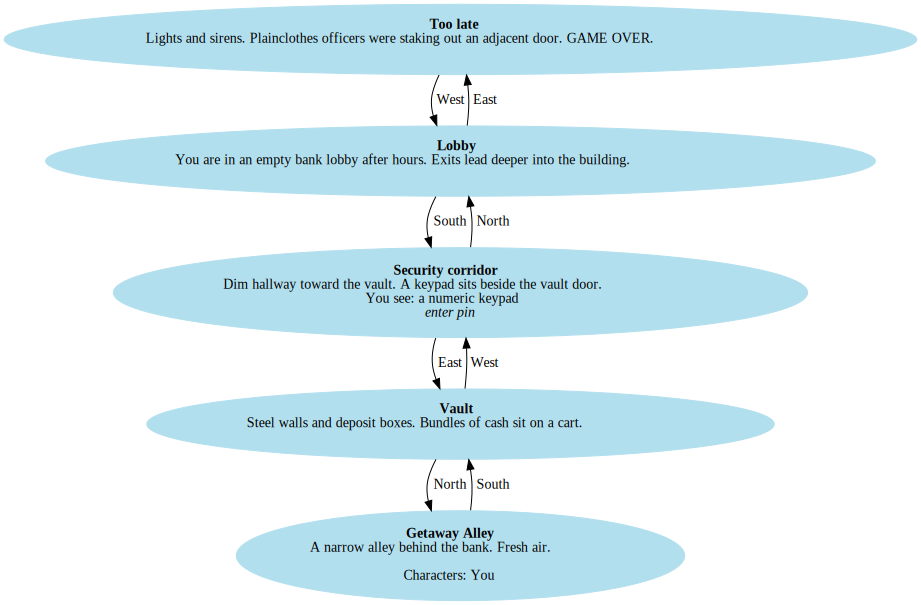

In [9]:
from text_adventure_games.viz import Visualizer

Visualizer(game).visualize()